# Phase D Validation: Evolutionary Dynamics
This notebook evaluates the behavioral dynamics and convergence properties of the `MemeticEngine` over generational search loops. We analyze three core dimensions of the search:
1. Convergence curves overlaid with the adaptive mutation rate orchestration from the `AdaptiveController`.
2. Preservation of core "trunk" routes across parent-child lineages to validate the Topological Hub Crossover.
3. An A/B cloning experiment comparing the heuristic efficacy and runtime of Epigenetic Pheromone Inheritance against expensive Native Pre-Simulations.
4. Multi-dimensional phenotypic convergence (Jaccard, Graph Edit Distance, and 2D Wasserstein Distance) overlaid with fitness variance collapse.

In [1]:
import os
import random
import yaml
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from tqdm.notebook import tqdm

# Set seeds for academic reproducibility
random.seed(42)
np.random.seed(42)

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']

from utils_simplified import (
    reuse_citygraph, reuse_ddm, generate_route_system, SimEnvironment, generate_dummy_yaml, run_simulations_parallel,
    build_pheromone_matrix, blend_pheromone_matrix, mutate_attraction, mutate_repulsion, mutate_pruning, crossover_routes,
    build_optimizer, process_telemetry, load_generation_snapshot
)
from utils.route import Route
from utils.jeep import Jeep
from utils.jeep_system import JeepSystem
from utils.genetic import Chromosome
from utils.evaluation_metrics import jaccard_similarity, graph_edit_distance, wasserstein_2d

### Optimization Run Setup
We load our cached CityGraph and DirectDemandSampler, build a temporary configuration file with short evaluation cycles (for runtime performance), and instantiate the `Optimizer`.

In [2]:
cg = reuse_citygraph("results_and_discussion/pkl/profile_p1.pkl")
ddm = reuse_ddm("results_and_discussion/pkl/ddm_8am.pkl")

os.makedirs("configs", exist_ok=True)
opt_yaml = "configs/opt_nb4.yaml"
generate_dummy_yaml(
    opt_yaml,
    **{
        "simulation.num_ticks": 300,
        "simulation.total_allocatable_jeeps": 40,
        "simulation.spawn_rate_per_hour": 120.0,
        "optimization.n_population": 8,
        "optimization.n_elite": 1,
        "optimization.g_max": 15,
        "optimization.k_tournament": 3,
        "optimization.telemetry_interval": 1,
        "optimization.checkpoint_interval": 1,
        "optimization.output_root": "outputs/opt_nb4",
        "cg_pkl": "results_and_discussion/pkl/profile_p1.pkl",
        "ddm_pkl": "results_and_discussion/pkl/ddm_8am.pkl"
    }
)

optimizer = build_optimizer(opt_yaml)
optimizer.runner = None
optimizer.engine.runner = None
print(f"Run directory: {optimizer.run_dir}")
print(f"Config: pop={optimizer.config.n_population}, g_max={optimizer.config.g_max}, ticks={optimizer.config.max_ticks}, jeeps={optimizer.config.total_allocatable_jeeps}")

[INFO] Reusing CityGraph from pickle file: results_and_discussion/pkl/profile_p1.pkl
[INFO] Reusing DirectDemandSampler from pickle file: results_and_discussion/pkl/ddm_8am.pkl
[INFO] Generating dummy YAML at configs/opt_nb4.yaml with overrides: {'simulation.num_ticks': 300, 'simulation.total_allocatable_jeeps': 40, 'simulation.spawn_rate_per_hour': 120.0, 'optimization.n_population': 8, 'optimization.n_elite': 1, 'optimization.g_max': 15, 'optimization.k_tournament': 3, 'optimization.telemetry_interval': 1, 'optimization.checkpoint_interval': 1, 'optimization.output_root': 'outputs/opt_nb4', 'cg_pkl': 'results_and_discussion/pkl/profile_p1.pkl', 'ddm_pkl': 'results_and_discussion/pkl/ddm_8am.pkl'}
[INFO] Building fresh Optimizer using config: configs/opt_nb4.yaml
[OPTIMIZER] Loading CityGraph from results_and_discussion/pkl/profile_p1.pkl
[OPTIMIZER] Loading DirectDemandSampler from results_and_discussion/pkl/ddm_8am.pkl
Run directory: outputs/opt_nb4/opt_20260603_170142
Config: pop=8

### Generational Memetic Pipeline Execution
To capture detailed structural route representations of chromosomes at every generation without relying entirely on disk serializations, we run the generational loop step-by-step in the notebook. This stores full in-memory `Chromosome` lists for downstream lineage and convergence calculations.

In [3]:
import time as _time
all_populations = {}
mutation_history = []
_pipeline_start = _time.time()

print("[GEN 0] Initializing population...")
_t0 = _time.time()
optimizer.state = optimizer.engine.initialize_state()
optimizer.telemetry.log_lineage(optimizer.state.population)
print(f"[GEN 0] Done in {_time.time()-_t0:.1f}s. Best={optimizer.state.best_fitness:.2f}")

# Deep copy population, preserving original UIDs for lineage tracking
all_populations[0] = [Chromosome(
    routes=[Route(path=r.path[:], city_graph=cg, id=r.id) for r in c.routes],
    allocation=c.allocation.copy(),
    pheromones=c.pheromones,
    generation=c.generation
) for c in optimizer.state.population]
for idx, c in enumerate(all_populations[0]):
    c.cost = optimizer.state.population[idx].cost
    c.uid = optimizer.state.population[idx].uid
    c.parents = optimizer.state.population[idx].parents

mutation_history.append(optimizer.config.p_mutation)

g_max = optimizer.config.g_max
for gen in range(1, g_max + 1):
    p_local = optimizer.adaptive.get_local_search_prob(gen, g_max)
    intensity = optimizer.adaptive.get_local_search_intensity(gen, g_max)
    
    current_mut = optimizer.config.p_mutation
    if optimizer.state.stagnation_counter > 0:
        stagnation_boost = optimizer.adaptive.update(optimizer.state.stagnation_counter) - optimizer.config.p_mutation
        p_local = min(p_local + max(0.0, stagnation_boost), 0.95)
        current_mut = min(optimizer.adaptive.update(optimizer.state.stagnation_counter), 0.95)
    
    _t0 = _time.time()
    optimizer.state = optimizer.engine.step_generation(optimizer.state, p_local, intensity=intensity)
    optimizer.state.generation = gen + 1
    _elapsed = _time.time() - _t0
    
    mean_cost = sum(c.cost for c in optimizer.state.population) / len(optimizer.state.population)
    total_elapsed = _time.time() - _pipeline_start
    print(f"[GEN {gen}/{g_max}] {_elapsed:.1f}s | Best={optimizer.state.best_fitness:.2f} Mean={mean_cost:.2f} | Stag={optimizer.state.stagnation_counter} p_mut={current_mut:.3f} | Total={total_elapsed:.0f}s")
    
    optimizer.telemetry.log_lineage(optimizer.state.population)
    optimizer.telemetry.log_generation(gen + 1, optimizer.state.best_fitness, mean_cost, p_local, optimizer.state.stagnation_counter)
    optimizer.telemetry.export_json_snapshot(gen + 1, optimizer.state.best_fitness, mean_cost, optimizer.state.population)
    
    gen_pop = [Chromosome(
        routes=[Route(path=r.path[:], city_graph=cg, id=r.id) for r in c.routes],
        allocation=c.allocation.copy(),
        pheromones=c.pheromones,
        generation=c.generation
    ) for c in optimizer.state.population]
    for idx, c in enumerate(gen_pop):
        c.cost = optimizer.state.population[idx].cost
        c.uid = optimizer.state.population[idx].uid
        c.parents = optimizer.state.population[idx].parents
    
    all_populations[gen] = gen_pop
    mutation_history.append(current_mut)

print(f"\nPipeline complete. Total wall time: {_time.time()-_pipeline_start:.0f}s")

[GEN 0] Initializing population...


[GEN 0] Done in 83.0s. Best=282910.29


[GEN 1/15] 173.5s | Best=272660.35 Mean=366004.58 | Stag=0 p_mut=0.250 | Total=257s


[GEN 2/15] 162.3s | Best=272660.35 Mean=399253.08 | Stag=1 p_mut=0.250 | Total=419s


[GEN 3/15] 191.2s | Best=264340.89 Mean=346260.85 | Stag=0 p_mut=0.251 | Total=611s


...

[GEN 11/15] 116.9s | Best=168342.17 Mean=324411.05 | Stag=1 p_mut=0.250 | Total=1956s


[GEN 12/15] 130.8s | Best=168342.17 Mean=316645.95 | Stag=2 p_mut=0.251 | Total=2088s


[GEN 13/15] 85.1s | Best=168342.17 Mean=314695.96 | Stag=3 p_mut=0.252 | Total=2174s


[GEN 14/15] 164.9s | Best=168342.17 Mean=359470.59 | Stag=4 p_mut=0.256 | Total=2339s


[GEN 15/15] 80.3s | Best=168342.17 Mean=268744.66 | Stag=5 p_mut=0.260 | Total=2420s

Pipeline complete. Total wall time: 2421s


## 1. Convergence and `AdaptiveController` Orchestration
This section evaluates the convergence of Best, Average, and Worst fitness scores across generations. We load the telemetry files and plot them overlaid with the dynamically scaling mutation rate governed by the stagnation feedback controller.

[INFO] Parsing history file: outputs/opt_nb4/opt_20260603_170142/history.csv
[INFO] Parsing lineage file: outputs/opt_nb4/opt_20260603_170142/lineage.csv


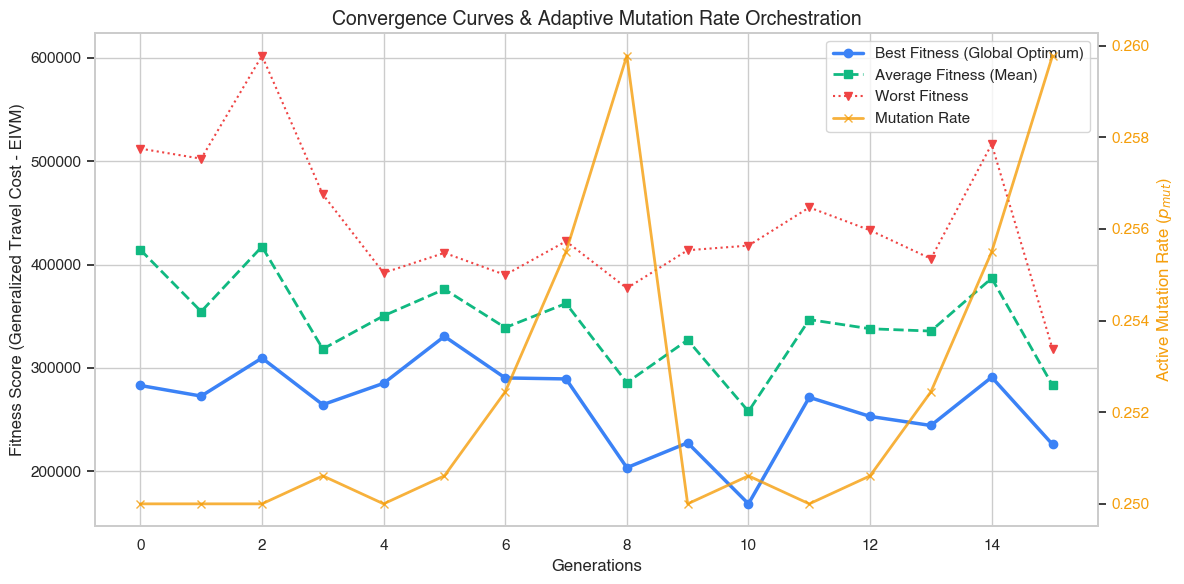

In [4]:
telemetry_data = process_telemetry(optimizer.run_dir)
df_lineage = telemetry_data["lineage"]

generations = sorted(df_lineage["Generation"].unique())
best_costs = []
mean_costs = []
worst_costs = []

for g in generations:
    costs = df_lineage[df_lineage["Generation"] == g]["Cost"]
    best_costs.append(costs.min())
    mean_costs.append(costs.mean())
    worst_costs.append(costs.max())

mut_rates = [mutation_history[g] if g < len(mutation_history) else mutation_history[-1] for g in generations]

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(generations, best_costs, label="Best Fitness (Global Optimum)", color="#3b82f6", linewidth=2.5, marker="o")
ax1.plot(generations, mean_costs, label="Average Fitness (Mean)", color="#10b981", linewidth=2.0, marker="s", linestyle="--")
ax1.plot(generations, worst_costs, label="Worst Fitness", color="#ef4444", linewidth=1.5, marker="v", linestyle=":")
ax1.set_xlabel("Generations", fontsize=12)
ax1.set_ylabel("Fitness Score (Generalized Travel Cost - EIVM)", fontsize=12)
ax1.set_title("Convergence Curves & Adaptive Mutation Rate Orchestration", fontsize=14, fontweight="bold")
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(generations, mut_rates, label="Mutation Rate", color="#f59e0b", linewidth=2.0, marker="x", alpha=0.8)
ax2.set_ylabel("Active Mutation Rate ($p_{mut}$)", color="#f59e0b", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#f59e0b")
ax2.grid(False)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

## 2. Trunk Preservation and Lineage Tracking
We trace the ancestry of the final generation's best chromosome back to generation 0. By isolating the top 15% highest-demand edges (corridors) of the elite configuration (the "trunk"), we verify that the crossover and mutation operators disproportionately preserve these trunk segments across the generational lineage.

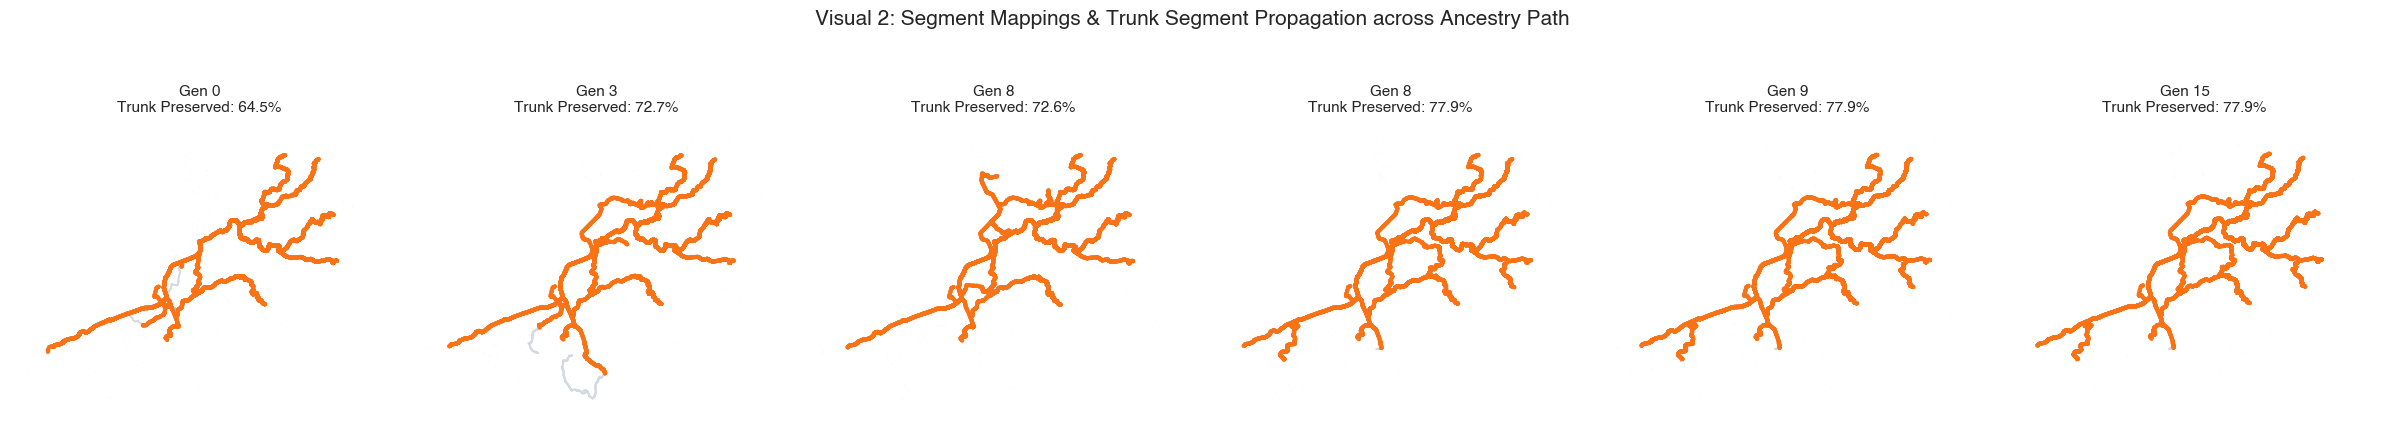

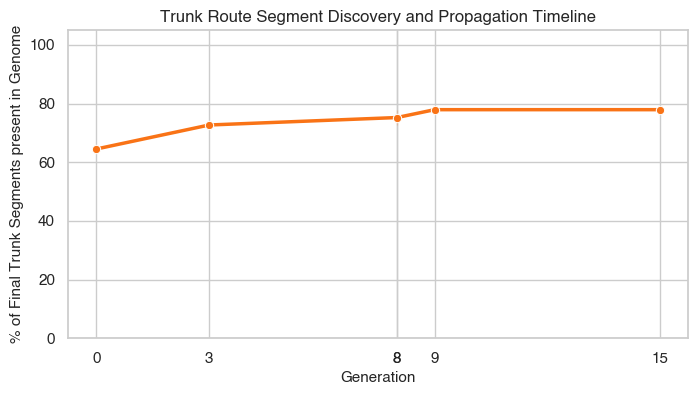

In [5]:
# 1. Identify best chromosome in final generation
best_chrom_final = sorted(all_populations[g_max], key=lambda c: c.cost)[0]

# 2. Identify the core "trunk" edges (top 15% highest pheromone edges in the final elite matrix)
best_matrix = best_chrom_final.pheromones
sorted_edges = sorted(best_matrix.tau.items(), key=lambda x: x[1], reverse=True)
top_k = max(2, int(len(sorted_edges) * 0.15))
top_edges = {e.id for e, tau in sorted_edges[:top_k]}

# 3. Trace back ancestors in memory
all_chroms_by_uid = {}
for gen, pop in all_populations.items():
    for c in pop:
        all_chroms_by_uid[c.uid] = (c, gen)

lineage_path = []
curr_uid = best_chrom_final.uid
while curr_uid:
    if curr_uid in all_chroms_by_uid:
        c, gen = all_chroms_by_uid[curr_uid]
        lineage_path.append((c, gen))
        curr_uid = c.parents[0] if c.parents else None
    else:
        break
lineage_path = lineage_path[::-1]  # from Gen 0 to Gen N

# 4. Calculate preservation percentages
generations_lineage = []
trunk_preservations = []
for c, gen in lineage_path:
    c_edges = {e.id for r in c.routes for e in r.path}
    shared = c_edges.intersection(top_edges)
    pct = (len(shared) / len(top_edges)) * 100 if top_edges else 0.0
    generations_lineage.append(gen)
    trunk_preservations.append(pct)

# 5. Plot maps of route segment preservation
def plot_lineage_generation(ax, chrom, top_edges, title):
    # Sample background roads to prevent over-cluttering
    for e in random.sample(list(cg.graph), min(800, len(cg.graph))):
        ax.plot([e.start.lon, e.end.lon], [e.start.lat, e.end.lat], color='#cbd5e1', alpha=0.15, linewidth=0.5)
        
    # Draw standard routes
    for r in chrom.routes:
        lons = [e.start.lon for e in r.path] + [r.path[-1].end.lon]
        lats = [e.start.lat for e in r.path] + [r.path[-1].end.lat]
        ax.plot(lons, lats, color='#94a3b8', linewidth=1.5, alpha=0.4)
        
    # Highlight final trunk edges
    for r in chrom.routes:
        for e in r.path:
            if e.id in top_edges:
                ax.plot([e.start.lon, e.end.lon], [e.start.lat, e.end.lat], color='#f97316', linewidth=3.0, alpha=0.95)
                
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")

fig, axes = plt.subplots(1, len(lineage_path), figsize=(4 * len(lineage_path), 4))
if len(lineage_path) == 1:
    axes = [axes]
for idx, (c, gen) in enumerate(lineage_path):
    plot_lineage_generation(axes[idx], c, top_edges, f"Gen {gen}\nTrunk Preserved: {trunk_preservations[idx]:.1f}%")
    
plt.suptitle("Visual 2: Segment Mappings & Trunk Segment Propagation across Ancestry Path", fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

# Render the timeline curve of preservation
plt.figure(figsize=(8, 4))
sns.lineplot(x=generations_lineage, y=trunk_preservations, marker="o", color="#f97316", linewidth=2.5)
plt.title("Trunk Route Segment Discovery and Propagation Timeline", fontsize=12, fontweight="bold")
plt.xlabel("Generation", fontsize=11)
plt.ylabel("% of Final Trunk Segments present in Genome", fontsize=11)
plt.ylim(0, 105)
plt.xticks(generations_lineage)
plt.show()

## 3. Heuristic Efficacy: Epigenetic Transfer vs. Native Pre-Simulation
To evaluate the value of **Epigenetic Pheromone Inheritance** ($w_A \tau^A + w_B \tau^B$), we duplicate a set of crossover offspring geometries to perform an A/B cloning experiment:
- **Twin A (Epigenetic):** Mutated under the guidance of the inherited parents' blended matrix ($O(1)$ arithmetic crossover).
- **Twin B (Control):** Forced to run an expensive microscopic simulation on its crossover geometry to build a native demand pheromone matrix prior to mutation.

We compare both twins in terms of their post-mutation fitness improvement ($F_{\text{sim}}$ delta) and the total computational runtime required.

[EXPERIMENT] Initiating A/B cloning tests across offspring geometries...
Evaluating baseline child 1...


  Pair 1: Twin A (Epigenetic) Improvement = 173753.83 in 0.490s | Twin B (Native) Improvement = 2104.70 in 7.311s
Evaluating baseline child 2...


  Pair 2: Twin A (Epigenetic) Improvement = 0.00 in 2.210s | Twin B (Native) Improvement = 0.00 in 7.186s
Evaluating baseline child 3...


  Pair 3: Twin A (Epigenetic) Improvement = 12356.17 in 0.465s | Twin B (Native) Improvement = 73137.16 in 28.947s
Evaluating baseline child 4...


  Pair 4: Twin A (Epigenetic) Improvement = 29470.42 in 2.113s | Twin B (Native) Improvement = 0.00 in 7.951s


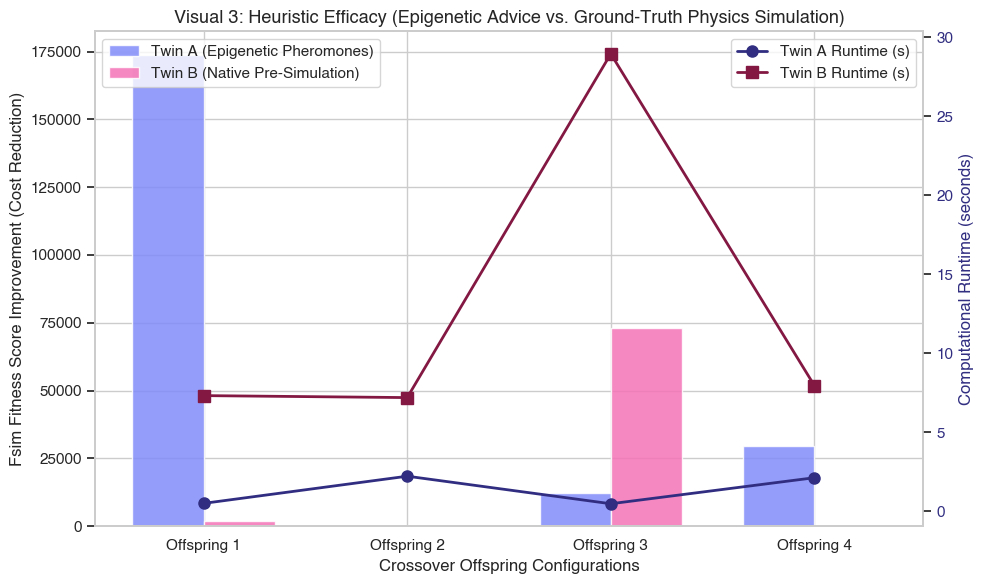

In [6]:
crossover_pairs = []
pop_last_gen = sorted(all_populations[g_max], key=lambda c: c.cost)

# Extract 4 distinct parent pairs from the final population
for idx in range(min(4, len(pop_last_gen) // 2)):
    crossover_pairs.append((pop_last_gen[idx * 2], pop_last_gen[idx * 2 + 1]))

improvements_A = []
improvements_B = []
runtimes_A = []
runtimes_B = []

print("[EXPERIMENT] Initiating A/B cloning tests across offspring geometries...")
for idx, (p1, p2) in enumerate(crossover_pairs):
    child_routes = crossover_routes(p1.routes, p1.pheromones, p2.routes, cg)
    
    # Measure baseline pre-mutation fitness
    print(f"Evaluating baseline child {idx+1}...")
    baseline_res = optimizer.fitness.evaluate(child_routes)
    baseline_fit = baseline_res.fitness_score
    
    # --- Twin A: Epigenetic Inheritance ---
    routes_A = [Route(path=r.path[:], city_graph=cg, id=r.id) for r in child_routes]
    start_A = time.time()
    
    blended_matrix = blend_pheromone_matrix(p1, p2, cg)
    blended_matrix.gaps = blended_matrix.calculate_demand_service_gaps(routes_A)
    optimizer.engine.algo.local_search.optimize_system(routes_A, blended_matrix, intensity=1.0)
    
    time_A = time.time() - start_A
    fit_A = optimizer.fitness.evaluate(routes_A).fitness_score
    
    # --- Twin B: Native Pre-Simulation ---
    routes_B = [Route(path=r.path[:], city_graph=cg, id=r.id) for r in child_routes]
    start_B = time.time()
    
    # Simulate child routes first to generate ground-truth passenger flows
    pre_sim_res = optimizer.fitness.evaluate(child_routes)
    native_matrix = build_pheromone_matrix(cg, pre_sim_res)
    native_matrix.gaps = native_matrix.calculate_demand_service_gaps(routes_B)
    optimizer.engine.algo.local_search.optimize_system(routes_B, native_matrix, intensity=1.0)
    
    time_B = time.time() - start_B
    fit_B = optimizer.fitness.evaluate(routes_B).fitness_score
    
    # Calculate improvement (positive value indicates cost reduction)
    improvements_A.append(max(0.0, baseline_fit - fit_A))
    improvements_B.append(max(0.0, baseline_fit - fit_B))
    runtimes_A.append(time_A)
    runtimes_B.append(time_B)
    
    print(f"  Pair {idx+1}: Twin A (Epigenetic) Improvement = {improvements_A[-1]:.2f} in {time_A:.3f}s | Twin B (Native) Improvement = {improvements_B[-1]:.2f} in {time_B:.3f}s")

# Render Twin A vs Twin B metrics
fig, ax1 = plt.subplots(figsize=(10, 6))
indices = np.arange(len(crossover_pairs))
width = 0.35

# Bars for improvements
ax1.bar(indices - width/2, improvements_A, width, label='Twin A (Epigenetic Pheromones)', color='#818cf8', alpha=0.85)
ax1.bar(indices + width/2, improvements_B, width, label='Twin B (Native Pre-Simulation)', color='#f472b6', alpha=0.85)
ax1.set_xlabel('Crossover Offspring Configurations', fontsize=12)
ax1.set_ylabel('Fsim Fitness Score Improvement (Cost Reduction)', fontsize=12)
ax1.set_title('Visual 3: Heuristic Efficacy (Epigenetic Advice vs. Ground-Truth Physics Simulation)', fontsize=13, fontweight='bold')
ax1.set_xticks(indices)
ax1.set_xticklabels([f"Offspring {i+1}" for i in indices])
ax1.legend(loc='upper left')

# Twin line plot for runtimes
ax2 = ax1.twinx()
ax2.plot(indices, runtimes_A, color='#312e81', marker='o', linewidth=2.0, markersize=8, label='Twin A Runtime (s)')
ax2.plot(indices, runtimes_B, color='#831843', marker='s', linewidth=2.0, markersize=8, label='Twin B Runtime (s)')
ax2.set_ylabel('Computational Runtime (seconds)', color='#312e81', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#312e81')
ax2.grid(False)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 4. Multi-Dimensional Phenotypic Convergence
We verify that the optimizer successfully avoids flat landscapes by proving convergence across three independent spatial dimensions: Jaccard Similarity (shared streets), Graph Edit Distance (topological connectivity), and 2D Wasserstein Distance (spatial demand coverage). We compute these metrics relative to each generation's elite chromosome and overlay them with the collapsing fitness variance of the population.

[METRICS] Computing phenotypic convergence across 16 generations...
  Gen 0: Jaccard=0.3627 GED=0.0000 Wass=0.012469 FitVar=4731743984.38
  Gen 1: Jaccard=0.4273 GED=0.0000 Wass=0.010670 FitVar=5878985057.94
  Gen 2: Jaccard=0.5974 GED=0.0000 Wass=0.007655 FitVar=9055849465.59
  Gen 3: Jaccard=0.8826 GED=0.0000 Wass=0.004960 FitVar=3888354048.37
  Gen 4: Jaccard=0.8346 GED=0.0000 Wass=0.004480 FitVar=2106070527.09
  Gen 5: Jaccard=0.8443 GED=0.0000 Wass=0.004179 FitVar=2260667487.95
  Gen 6: Jaccard=0.7627 GED=0.0000 Wass=0.003532 FitVar=1604878041.14
  Gen 7: Jaccard=0.7700 GED=0.0000 Wass=0.004050 FitVar=2782669371.11
  Gen 8: Jaccard=0.9617 GED=0.0000 Wass=0.003666 FitVar=3052684194.15
  Gen 9: Jaccard=1.0000 GED=0.0000 Wass=0.003803 FitVar=4655771105.18
  Gen 10: Jaccard=1.0000 GED=0.0000 Wass=0.005850 FitVar=6577108593.93
  Gen 11: Jaccard=1.0000 GED=0.0000 Wass=0.003720 FitVar=6800184792.46
  Gen 12: Jaccard=1.0000 GED=0.0000 Wass=0.003428 FitVar=6003790192.61
  Gen 13: Jaccard=1

/var/folders/rx/kblrj3c10fv8wymvkvn_nh7r0000gn/T/ipykernel_41013/2311394378.py:85: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/var/folders/rx/kblrj3c10fv8wymvkvn_nh7r0000gn/T/ipykernel_41013/2311394378.py:85: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniforge/base/envs/thesis-py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8593 (\N{UPWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniforge/base/envs/thesis-py311/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8595 (\N{DOWNWARDS ARROW}) missing from font(s) Helvetica.
  fig.canvas.print_figure(bytes_io, **kw)


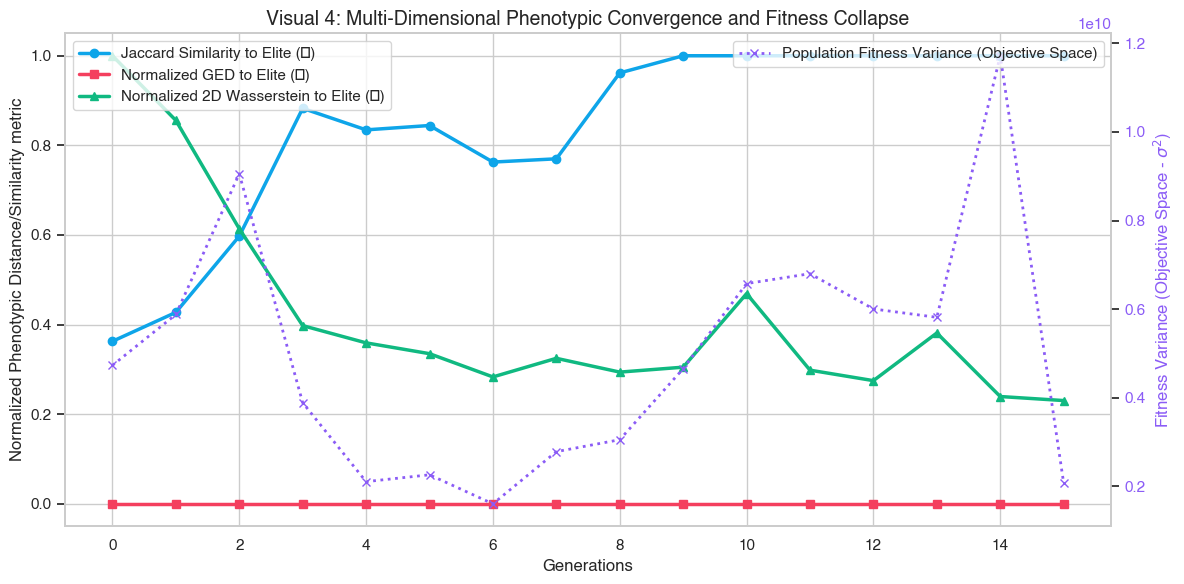

In [7]:
mean_jaccards = []
mean_geds = []
mean_wassersteins = []
fitness_variances = []

# FIX: Helper to deduplicate edge coordinates AND sample to a tractable size.
# The wasserstein_2d LP solver builds an (n+m, n*m) constraint matrix. With ~5000
# unique coords per chromosome, n*m = ~25M decision variables, causing 800 GiB OOM.
# Weighted sampling to 200 points keeps the LP tractable (200*200 = 40K variables).
MAX_WASSERSTEIN_POINTS = 200

def _sample_coord_weights(routes, pheromones, max_pts):
    """Deduplicate edges by coordinate, then sample to max_pts for Wasserstein."""
    coord_weights = {}
    for r in routes:
        for e in r.path:
            key = (e.start.lat, e.start.lon)
            coord_weights[key] = coord_weights.get(key, 0.0) + pheromones.tau.get(e, 1.0)
    coords = list(coord_weights.keys())
    weights = list(coord_weights.values())
    if len(coords) > max_pts:
        w_arr = np.array(weights)
        w_arr = w_arr / w_arr.sum()
        indices = np.random.choice(len(coords), size=max_pts, replace=False, p=w_arr)
        coords = [coords[i] for i in indices]
        weights = [weights[i] for i in indices]
    return coords, weights

print(f"[METRICS] Computing phenotypic convergence across {g_max+1} generations...")
for gen in range(g_max + 1):
    pop = all_populations[gen]
    pop_sorted = sorted(pop, key=lambda c: c.cost)
    elite = pop_sorted[0]
    
    elite_edges = set(e for r in elite.routes for e in r.path)
    elite_coords, elite_weights = _sample_coord_weights(elite.routes, elite.pheromones, MAX_WASSERSTEIN_POINTS)
    
    jaccards = []
    geds = []
    wassersteins = []
    
    for chrom in pop_sorted[1:]:
        chrom_edges = set(e for r in chrom.routes for e in r.path)
        jaccards.append(jaccard_similarity(elite_edges, chrom_edges))
        geds.append(graph_edit_distance(elite_edges, chrom_edges, max_nodes=8))
        
        chrom_coords, chrom_weights = _sample_coord_weights(chrom.routes, chrom.pheromones, MAX_WASSERSTEIN_POINTS)
        try:
            w_dist = wasserstein_2d(elite_coords, elite_weights, chrom_coords, chrom_weights)
        except Exception:
            w_dist = 0.0
        wassersteins.append(w_dist)
        
    mean_jaccards.append(np.mean(jaccards))
    mean_geds.append(np.mean(geds))
    mean_wassersteins.append(np.mean(wassersteins))
    
    costs = [c.cost for c in pop]
    fitness_variances.append(np.var(costs))
    print(f"  Gen {gen}: Jaccard={np.mean(jaccards):.4f} GED={np.mean(geds):.4f} Wass={np.mean(wassersteins):.6f} FitVar={np.var(costs):.2f}")

# Normalize GED and Wasserstein to start at 1.0 for visual comparison of convergence rates
norm_jaccards = np.array(mean_jaccards)
norm_geds = np.array(mean_geds) / (mean_geds[0] if mean_geds[0] > 0 else 1.0)
norm_wassersteins = np.array(mean_wassersteins) / (mean_wassersteins[0] if mean_wassersteins[0] > 0 else 1.0)

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(range(g_max + 1), norm_jaccards, label="Jaccard Similarity to Elite (↑)", color="#0ea5e9", linewidth=2.5, marker="o")
ax1.plot(range(g_max + 1), norm_geds, label="Normalized GED to Elite (↓)", color="#f43f5e", linewidth=2.5, marker="s")
ax1.plot(range(g_max + 1), norm_wassersteins, label="Normalized 2D Wasserstein to Elite (↓)", color="#10b981", linewidth=2.5, marker="^")
ax1.set_xlabel("Generations", fontsize=12)
ax1.set_ylabel("Normalized Phenotypic Distance/Similarity metric", fontsize=12)
ax1.set_ylim(-0.05, 1.05)
ax1.set_title("Visual 4: Multi-Dimensional Phenotypic Convergence and Fitness Collapse", fontsize=14, fontweight="bold")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(range(g_max + 1), fitness_variances, label="Population Fitness Variance (Objective Space)", color="#8b5cf6", linewidth=2.0, marker="x", linestyle=":")
ax2.set_ylabel("Fitness Variance (Objective Space - $\\sigma^2$)", color="#8b5cf6", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#8b5cf6")
ax2.grid(False)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

# Final cleanups of dummy YAML file
try:
    if os.path.exists(opt_yaml):
        os.remove(opt_yaml)
except Exception as e:
    pass